# Linear Regression and Generalization

How does adding fitted features change training and test error? This synthetic experiment holds the data-generating rule fixed and varies the number of features used by a least-squares model.

Run the cells in order with NumPy and Matplotlib installed. Repeated pseudoinverse calculations can take time. For a quick check, reduce <code>num_of_trials</code>; the saved figures use 20 trials.


## Define the Data-Generating Model

There are 50 observations per dataset, at most 250 candidate features, and only 10 features with nonzero true coefficients. The coefficient vector is normalized to length 1. Independent Gaussian noise has standard deviation 0.2.

The seed fixes the experiment's random sequence. Training and test samples will be drawn independently but use the same true coefficient vector.


In [ ]:
# linear regression on synthetic data

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

s = 10 # number of true features
beta_star = np.random.randn(s)
# normalize beta_star
beta_star /= np.linalg.norm(beta_star)
n = 50 # number of samples
p_max = 250 # max possible number of features
sigma = 0.2 # noise level



## Generate One Dataset

The matrix has shape <code>(250, 50)</code>: **features are rows and observations are columns**, the transpose of a common machine-learning convention. Only the first ten feature rows contribute to the response.

The expression <code>X[:s, :].T @ beta_star</code> produces one noiseless response per observation; the noise vector adds independent measurement error.


In [ ]:
def generate_samples():
    """
    Generate synthetic data for linear regression.
    """
    X = np.random.randn(p_max, n)
    noise = sigma * np.random.randn(n) # generate noise
    # generate response variable
    y = X[:s, :].T @ beta_star + noise
    return X, y



## Choose Model Sizes

The first range uses 1 through 48 fitted features; the second uses 52 through 250. The near-interpolation values 49, 50, and 51 are excluded, matching the undefined or divergent expected-error cases in the theoretical comparison.

The lists separately collect training and test error for the two ranges.


In [ ]:
p_under = list(range(1, n-1))
p_over = list(range(n+2, p_max+1))
err_under = []
err_over = []
train_err_under = []
train_err_over = []



## Fit and Measure Error

The function selects the first <code>p</code> features and computes least squares using the **Moore-Penrose pseudoinverse**. When there are more features than observations, this selects the minimum-Euclidean-norm least-squares solution.

Both returned quantities are mean squared error (MSE): the average squared difference between response and prediction. Test predictions use the fitted training coefficients without refitting. Training error and generalization error answer different questions.


In [ ]:
def compute_error(X_train, y_train, X_test, y_test, p):
    """
    Compute training and test errors for linear regression.
    """
    X = X_train[:p, :] # select first p features
    beta = np.linalg.pinv(X.T) @ y_train # compute beta
    train_error = np.mean((y_train - X.T @ beta) ** 2) # compute train error
    X = X_test[:p, :] # select first p features
    y_pred = X.T @ beta # compute predictions
    test_error = np.mean((y_test - y_pred) ** 2) # compute test error
    return train_error, test_error



## Repeat on Independent Datasets

Each trial draws fresh training and test data, then fits every requested model size on those same datasets. Sharing data within a trial makes comparisons across feature counts more meaningful.

Error lists have one row per trial and one column per model size. This cell performs the calculations; the following cells summarize and plot the stored results.


In [ ]:
num_of_trials = 20
for ii in range(num_of_trials):
    X_train, y_train = generate_samples()
    X_test, y_test = generate_samples() # generate test data
    test_errors_under = []
    test_errors_over = []
    train_errors_under = []
    train_errors_over = []
    for p in p_under:
        train_error, test_error = compute_error(X_train, y_train, X_test, y_test, p)
        test_errors_under.append(test_error)
        train_errors_under.append(train_error)
    for p in p_over:
        train_error, test_error = compute_error(X_train, y_train, X_test, y_test, p)
        test_errors_over.append(test_error)
        train_errors_over.append(train_error)
    # store errors
    err_under.append(test_errors_under)
    err_over.append(test_errors_over)
    train_err_under.append(train_errors_under)
    train_err_over.append(train_errors_over)

## Summarize Test Error

The mean is computed across trials at each feature count. The shaded band will span the minimum and maximum observed trial errors. It is **not** a confidence interval or a standard-deviation band.


In [ ]:
err_under_max = np.max(err_under, axis=0)
err_under_min = np.min(err_under, axis=0)
err_over_max = np.max(err_over, axis=0)
err_over_min = np.min(err_over, axis=0)

err_under_mean = np.mean(err_under, axis=0)
err_over_mean = np.mean(err_over, axis=0)



## Plot Generalization

Both axes use logarithmic scales. Compare the initial benefit of adding true features with the instability near the interpolation threshold.

The saved legend says "Underfitting" and "Overfitting," but its colors actually identify **underparameterized** (<code>p < n</code>) and **overparameterized** (<code>p > n</code>) ranges. Parameter count alone does not establish whether a model overfits.


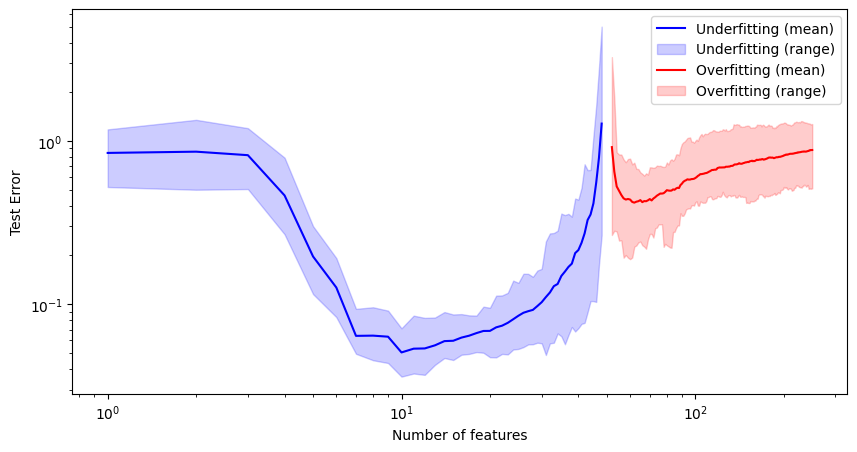

In [ ]:
plt.figure(figsize=(10, 5))

# Plot underfitting errors
plt.plot(p_under, err_under_mean, label='Underfitting (mean)', color='blue')
plt.fill_between(p_under, err_under_min, err_under_max, color='blue', alpha=0.2, label='Underfitting (range)')

# Plot overfitting errors
plt.plot(p_over, err_over_mean, label='Overfitting (mean)', color='red')
plt.fill_between(p_over, err_over_min, err_over_max, color='red', alpha=0.2, label='Overfitting (range)')

plt.xlabel('Number of features')
plt.ylabel('Test Error')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()



## Plot Training Error

The training curve uses a linear vertical axis. In the overparameterized range, a full-row-rank design can fit all training responses, including noise, so training error is numerically near zero.

Compare this with the nonzero test error. Interpolating the training data does not make unseen noisy responses perfectly predictable.


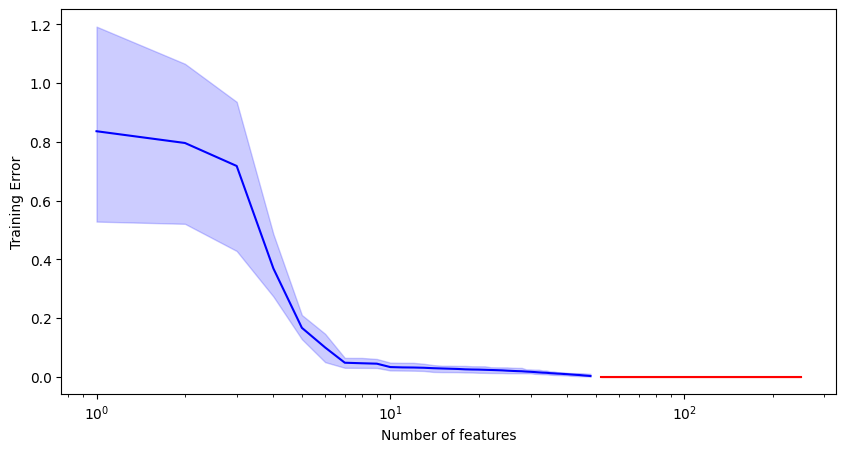

In [ ]:
# show the training errors in another figure

train_err_under_max = np.max(train_err_under, axis=0)
train_err_under_min = np.min(train_err_under, axis=0)
train_err_over_max = np.max(train_err_over, axis=0)
train_err_over_min = np.min(train_err_over, axis=0)
train_err_under_mean = np.mean(train_err_under, axis=0)
train_err_over_mean = np.mean(train_err_over, axis=0)

plt.figure(figsize=(10, 5))
# Plot underfitting training errors
plt.plot(p_under, train_err_under_mean, label='Underfitting (mean)', color='blue')
plt.fill_between(p_under, train_err_under_min, train_err_under_max, color='blue', alpha=0.2, label='Underfitting (range)')
# Plot overfitting training errors
plt.plot(p_over, train_err_over_mean, label='Overfitting (mean)', color='red')
plt.fill_between(p_over, train_err_over_min, train_err_over_max, color='red', alpha=0.2, label='Overfitting (range)')
plt.xlabel('Number of features')
plt.ylabel('Training Error')
# plt.yscale('log')
plt.xscale('log')
plt.show()

## Expected Test Error Under This Model

The formula assumes the isotropic Gaussian features, independent Gaussian noise, and unregularized minimum-norm estimator used here. It is not a universal law for arbitrary datasets.

For <code>p < s</code>, omitted true coefficients contribute extra unexplained variation. Once all true features are included, that term disappears. Above the interpolation threshold, the expression combines signal bias with noise and estimation terms. The function returns <code>None</code> around the singular threshold rather than drawing a finite value there.


In [ ]:
def theoretical_test_error(p, n, s, sigma, beta_star):
    """
    Compute the theoretical test error for linear regression.
    """
    if p >= n-1 and p <= n+1:
        return None
    if p < s:
        return (np.sum(beta_star[p:] ** 2) + sigma ** 2) * ((n - 1) / (n - p - 1))
    if p < n - 1:
        return (n - 1) / (n - p - 1) * sigma ** 2
    return (1 - n / p) * np.sum(beta_star ** 2) + sigma ** 2 + n / (p - n - 1) * sigma ** 2



## Compare Theory with the Simulation

The dashed curves show the model's expected test error, while the earlier curves are finite-trial estimates. Compare their trends, especially near the threshold, where variability is large.

The noise variance is <code>sigma ** 2 = 0.04</code>. Even knowing the true coefficients would leave that expected error when predicting a fresh noisy response.


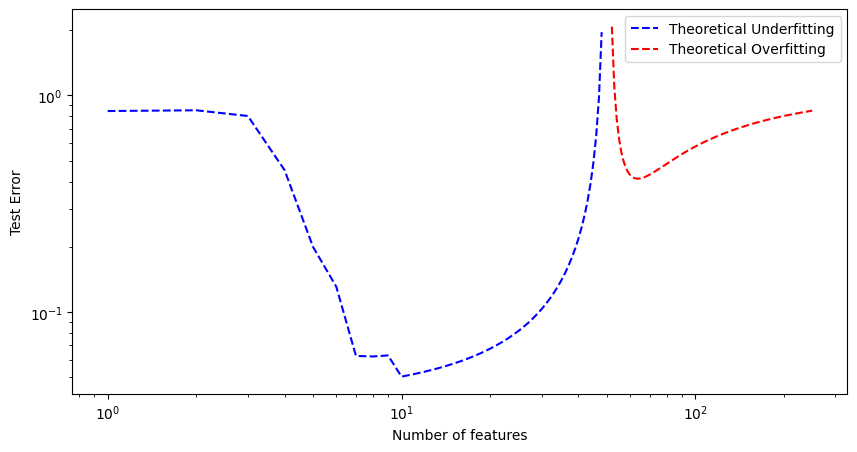

In [ ]:
p = np.array(p_under + p_over)
theoretical_errors = []
for pp in p:
    theoretical_errors.append(theoretical_test_error(pp, n, s, sigma, beta_star))
theoretical_errors = np.array(theoretical_errors)
theoretical_errors_under = theoretical_errors[:len(p_under)]
theoretical_errors_over = theoretical_errors[len(p_under):]
plt.figure(figsize=(10, 5))
# Plot theoretical errors
plt.plot(p_under, theoretical_errors_under, label='Theoretical Underfitting', color='blue', linestyle='--')
plt.plot(p_over, theoretical_errors_over, label='Theoretical Overfitting', color='red', linestyle='--')
plt.xlabel('Number of features')
plt.ylabel('Test Error')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

## Questions to Explore

- Why does using fewer than ten features omit part of the true signal?
- Why can training error keep falling while test error rises?
- Change the noise level and rerun the experiment. Which part of the theoretical expression changes?
- Why might a small number of trials give an unstable average near interpolation?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **The omitted features carry real signal.** The response uses the first ten feature coordinates with nonzero coefficients. A fit with `p < 10` cannot represent the contribution from coordinates p through 9. Because the features are independent Gaussian variables, that omitted contribution has variance `sum(beta_star[p:] ** 2)` and cannot be recovered from the included features alone.
2. **Fitting noise is not generalization.** Adding features cannot worsen the best achievable training least-squares fit, and enough features can interpolate the noisy training responses. Near the interpolation threshold, poorly determined directions can amplify noise and make predictions unstable on independent test examples. Thus training error can fall while test error rises; the full test-error curve need not be monotone on either side of the threshold.
3. **The noise-dependent terms change with sigma squared.** The omitted-signal term and coefficient norm stay fixed. The irreducible noise variance and the noise-amplification terms all depend on `sigma ** 2`. Doubling sigma quadruples those contributions; for example, the irreducible error changes from 0.04 to 0.16. It does not quadruple any separate signal-bias contribution.
4. **Rare unstable fits can dominate a small average.** Near interpolation, a random design can have very small singular values. Taking their reciprocals in the pseudoinverse amplifies noise and can produce exceptionally large test errors. A small set of trials may include or miss such cases, making its mean and min-to-max band unstable. More trials help away from the excluded singular cases, but do not turn a divergent expected error into a finite one.

</details>

**Takeaway:** training fit, model size, and generalization are not interchangeable. The estimator and the data-generating assumptions matter.
